# Time dependent analysis

This tutorial shows how to use the public point-source data for a time dependent point-source analysis with the public 10-year IceCube point-source data. The time fit is performed by the expectation maximization (EM) algorithm.   

In [1]:
from matplotlib import pyplot as plt

import skyllh
from skyllh.analyses.i3.publicdata_ps.time_dependent_ps import (
    TXS_0506_PLUS056_ALERT_TIME,
    TXS_0506_PLUS056_SOURCE,
    create_analysis,
    do_trials_with_em,
    unblind_single_flare,
)
from skyllh.core.config import Config

First we need to create a local configuration for the analysis. We will create just the default configuration:

In [2]:
cfg = Config()

Now we can get the dataset:

In [3]:
datasets = skyllh.create_datasets('IceTracks-DR1', cfg=cfg, names=['IC86_II-VII'])

We create the ``Analysis`` instance for the TXS 0506+056 source.

In [4]:
ana = create_analysis(
    cfg=cfg, datasets=datasets, source=TXS_0506_PLUS056_SOURCE, refplflux_gamma=2.0, gauss={'mu': 57000, 'sigma': 65}
)

100%|██████████| 44/44 [00:00<00:00, 8892.23it/s]


In [5]:
(best_ts, best_em_result, best_fitparam_values) = unblind_single_flare(ana=ana, remove_time=TXS_0506_PLUS056_ALERT_TIME)

100%|██████████| 51/51 [00:03<00:00, 16.73it/s]


In [6]:
print(f'best TS = {best_ts:g}')
print(f'best em mu = {best_em_result["mu"]:g}')
print(f'best em sigma = {best_em_result["sigma"]:g}')
print(f'best ns = {best_fitparam_values[0]:g}')
print(f'best gamma = {best_fitparam_values[1]:g}')

best TS = 15.6274
best em mu = 56972.1
best em sigma = 27.7518
best ns = 7.47078
best gamma = 2.22252


Run background trials, i.e. ``mean_n_sig=0``

In [7]:
bg_trials = do_trials_with_em(ana=ana, n=100, mean_n_sig=0, ncpu=4)

100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


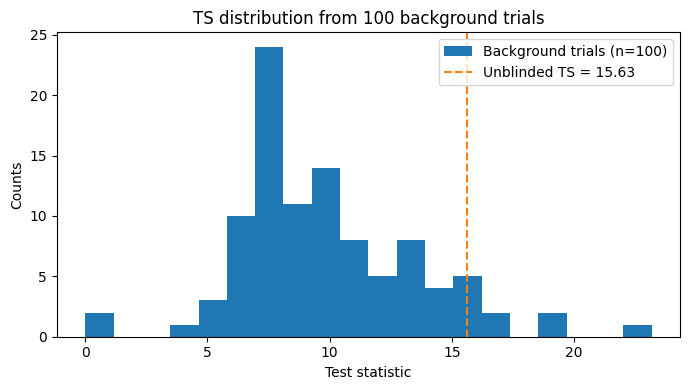

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bg_trials['ts'], bins=20, label='Background trials (n=100)')
ax.axvline(best_ts, color='C1', linestyle='--', label=f'Unblinded TS = {best_ts:.2f}')
ax.set_xlabel('Test statistic')
ax.set_ylabel('Counts')
ax.set_title('TS distribution from 100 background trials')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the EM parameters

The EM algorithm fits a Gaussian time profile with two parameters:
- **`mu`** (MJD): the best-fit arrival time of the flare (centre of the Gaussian)
- **`sigma`** (days): the best-fit duration of the flare (standard deviation of the Gaussian)

The known alert time for TXS 0506+056 is MJD 58018.87 (22 September 2017).
Converting `best_em_result["mu"]` to a calendar date and comparing with this reference tells us how well
the EM algorithm recovered the timing of the known multi-messenger event.

In [9]:
from astropy.time import Time

best_mu_mjd = best_em_result['mu']
best_sigma_days = best_em_result['sigma']

best_date = Time(best_mu_mjd, format='mjd').iso
print(f'Best-fit flare time: MJD {best_mu_mjd:.1f} ({best_date})')
print(f'Best-fit flare duration (1 sigma): {best_sigma_days:.1f} days')
print(
    f'Offset from alert time (MJD {TXS_0506_PLUS056_ALERT_TIME:.2f}): '
    f'{best_mu_mjd - TXS_0506_PLUS056_ALERT_TIME:.1f} days'
)

Best-fit flare time: MJD 56972.1 (2014-11-11 03:23:27.294)
Best-fit flare duration (1 sigma): 27.8 days
Offset from alert time (MJD 58018.87): -1046.7 days


In [10]:
from skyllh.core.utils.analysis import calculate_pval_from_trials

ts_vals = bg_trials['ts']
(p_val, p_val_sigma) = calculate_pval_from_trials(ts_vals, best_ts)
print(f'p-value from {len(ts_vals)} background trials: {p_val:.3f} ± {p_val_sigma:.3f}')
print()
print('Note: 100 trials is illustrative — the estimate is very noisy at this level.')
print('For a reliable p-value at TS ≈ 15, use the gamma-fit method from p_value_method_comparison.ipynb.')

p-value from 100 background trials: 0.070 ± 0.026

Note: 100 trials is illustrative — the estimate is very noisy at this level.
For a reliable p-value at TS ≈ 15, use the gamma-fit method from p_value_method_comparison.ipynb.


### Applying this analysis to other sources

To apply the time-dependent analysis to a different source:

1. Define a ``PointLikeSource`` with the source coordinates.
2. Call ``create_analysis`` with the new source and appropriate EM Gaussian priors (``gauss={'mu': ..., 'sigma': ...}``).
3. Call ``unblind_single_flare`` to find the best-fit flare parameters.
4. Generate background trials with ``do_trials_with_em`` and compute the p-value with ``calculate_pval_from_trials``.

For production-level significance estimates, generate at least a few thousand background trials.